In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("loan_risk_ews.csv")
df.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,CKV34LU7V7,55,112656,92393,581,113,2,23.54,36,0.15,PhD,Self-employed,Single,Yes,Yes,Home,No,0
1,62KTYNH93J,56,91569,131575,641,54,1,15.19,12,0.43,High School,Part-time,Divorced,Yes,Yes,Education,Yes,0
2,JGFUSOIUH7,26,78169,75417,569,105,3,18.02,12,0.29,Master's,Part-time,Married,Yes,Yes,Education,Yes,0
3,4538THBHOX,26,63033,10804,326,118,1,14.71,24,0.41,High School,Part-time,Single,No,No,Business,Yes,0
4,DXLNA06JHR,24,29665,21182,662,102,3,15.02,60,0.69,PhD,Unemployed,Single,No,Yes,Business,Yes,0


In [3]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75000 entries, 0 to 74999
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   LoanID          75000 non-null  object 
 1   Age             75000 non-null  int64  
 2   Income          75000 non-null  int64  
 3   LoanAmount      75000 non-null  int64  
 4   CreditScore     75000 non-null  int64  
 5   MonthsEmployed  75000 non-null  int64  
 6   NumCreditLines  75000 non-null  int64  
 7   InterestRate    75000 non-null  float64
 8   LoanTerm        75000 non-null  int64  
 9   DTIRatio        75000 non-null  float64
 10  Education       75000 non-null  object 
 11  EmploymentType  75000 non-null  object 
 12  MaritalStatus   75000 non-null  object 
 13  HasMortgage     75000 non-null  object 
 14  HasDependents   75000 non-null  object 
 15  LoanPurpose     75000 non-null  object 
 16  HasCoSigner     75000 non-null  object 
 17  Default         75000 non-null 

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Default
count,75000.000000,75000.000000,75000.00000,75000.000000,75000.000000,75000.000000,75000.000000,75000.000000,75000.000000,75000.000000
mean,43.536560,82530.589493,127608.09136,575.364000,59.627667,2.497067,13.513907,36.097280,0.499440,0.116507
std,14.992572,39011.030858,70848.96454,158.714226,34.650788,1.117238,6.632378,17.037131,0.230893,0.320834
min,18.000000,15000.000000,5000.00000,300.000000,0.000000,1.000000,2.000000,12.000000,0.100000,0.000000
25%,31.000000,48716.500000,66281.50000,438.000000,30.000000,1.000000,7.810000,24.000000,0.300000,0.000000
50%,43.000000,82655.000000,127424.00000,575.000000,60.000000,2.000000,13.470000,36.000000,0.500000,0.000000
75%,57.000000,116254.750000,189144.50000,713.000000,90.000000,3.000000,19.270000,48.000000,0.700000,0.000000
max,69.000000,149994.000000,249992.00000,849.000000,119.000000,4.000000,25.000000,60.000000,0.900000,1.000000


In [4]:
# Check missing
df.isnull().sum()

LoanID            0
Age               0
Income            0
LoanAmount        0
CreditScore       0
MonthsEmployed    0
NumCreditLines    0
InterestRate      0
LoanTerm          0
DTIRatio          0
Education         0
EmploymentType    0
MaritalStatus     0
HasMortgage       0
HasDependents     0
LoanPurpose       0
HasCoSigner       0
Default           0
dtype: int64

In [5]:
# Convert Yes/No to Binary
df['HasMortgage'] = df['HasMortgage'].map({'Yes':1, 'No':0})
df['HasDependents'] = df['HasDependents'].map({'Yes':1, 'No':0})
df['HasCoSigner'] = df['HasCoSigner'].map({'Yes':1, 'No':0})

In [6]:
# Feature Engineering

In [7]:
# Loan-to-Income Ratio
df['Loan_to_Income'] = df['LoanAmount'] / df['Income']

In [8]:
# Credit Risk Factor (lower credit score = higher risk)
df['Credit_Risk_Factor'] = 850 - df['CreditScore']

In [9]:
# Employment Stability Score
df['Employment_Stability'] = df['MonthsEmployed'] / df['MonthsEmployed'].max()

In [10]:
# Normalize Risk Features
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

risk_cols = [
    'DTIRatio',
    'Loan_to_Income',
    'Credit_Risk_Factor',
    'InterestRate'
]

df[risk_cols] = scaler.fit_transform(df[risk_cols])

In [11]:
# Create Risk Score
df['Risk_Score'] = (
    0.30 * df['DTIRatio'] +
    0.25 * df['Loan_to_Income'] +
    0.20 * df['Credit_Risk_Factor'] +
    0.15 * df['InterestRate'] +
    0.10 * (1 - df['Employment_Stability'])
)

df['Risk_Score'] = df['Risk_Score'] * 100

df[['Risk_Score']].head()

,Risk_Score
0,27.381519
1,36.142629
2,30.360149
3,39.259257
4,39.887785


In [12]:
# Risk Segmentation
def risk_category(score):

    if score < 40:
        return "Low Risk"
    
    elif score < 70:
        return "Medium Risk"
    
    else:
        return "High Risk"


df['Risk_Category'] = df['Risk_Score'].apply(risk_category)

df['Risk_Category'].value_counts()

Risk_Category
Medium Risk    38478
Low Risk       36101
High Risk        421
Name: count, dtype: int64

In [13]:
# Early Warning Flag
df['Early_Warning'] = np.where(

    (df['Risk_Score'] > 75) |
    (df['DTIRatio'] > 0.6) |
    (df['CreditScore'] < 500),

    1,
    0
)

df['Early_Warning'].value_counts()

Early_Warning
1    45977
0    29023
Name: count, dtype: int64

In [14]:
# Default Rate
default_rate = df['Default'].mean() * 100

print("Default Rate %:", round(default_rate,2))

Default Rate %: 11.65


In [15]:
# Default by Risk Category
pd.crosstab(

    df['Risk_Category'],
    df['Default'],

    normalize='index'
) * 100

Default,0,1
Risk_Category,,
High Risk,55.581948,44.418052
Low Risk,92.133182,7.866818
Medium Risk,85.157752,14.842248


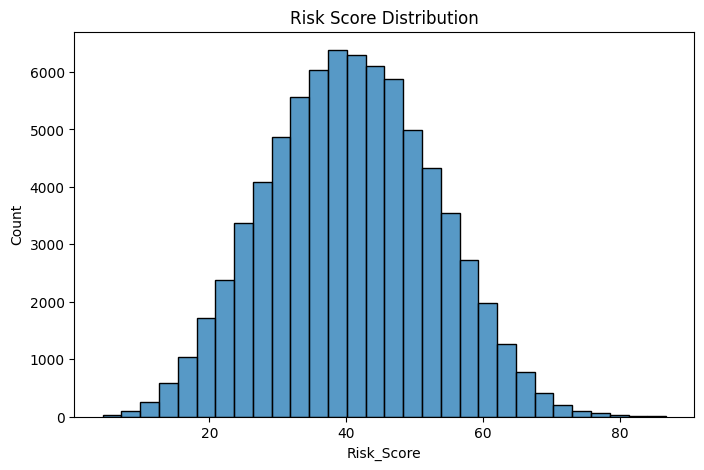

In [16]:
# Risk Distribution Plot
plt.figure(figsize=(8,5))

sns.histplot(

    df['Risk_Score'],
    bins=30

)

plt.title("Risk Score Distribution")

plt.show()

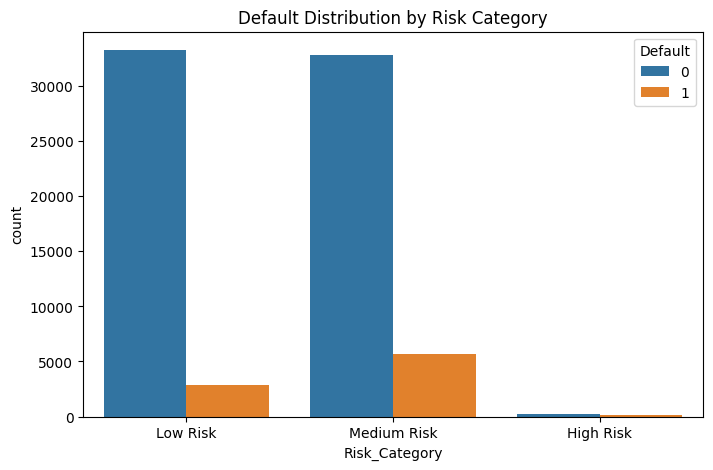

In [17]:
# Default vs Risk Category
plt.figure(figsize=(8,5))

sns.countplot(

    x='Risk_Category',
    hue='Default',
    data=df

)

plt.title("Default Distribution by Risk Category")

plt.show()

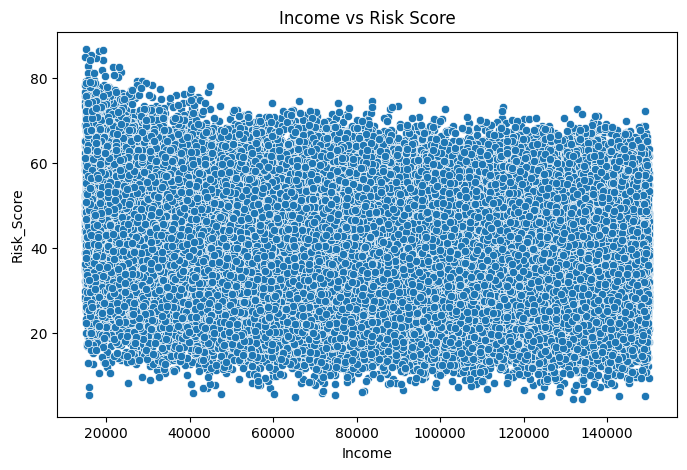

In [18]:
# Income vs Risk
plt.figure(figsize=(8,5))

sns.scatterplot(

    x=df['Income'],
    y=df['Risk_Score']

)

plt.title("Income vs Risk Score")

plt.show()

In [19]:
df.to_csv(

    "credit_risk_ews_final.csv",
    index=False

)

print("File saved successfully")

File saved successfully
